In [145]:
import numpy as np
import pandas as pd
from numpy.random import default_rng
import pickle
from pathlib import Path

# ==============================
# Global constants
# ==============================

OMEGA = 2 * np.pi / 365.0  # annual frequency for sin/cos seasonality


# ==============================
# Mean temperature model (eq. 3.9)
# ==============================

def _fit_mean_model(df_region: pd.DataFrame) -> dict:
    """
    Fit T^m_t = a1 + a2 t + a3 sin(ω t) + a4 cos(ω t)
    as in eq. (3.9) of Alaton et al. (2002).

    df_region must have columns: "date", "daily_avg_temperature".
    """
    df = df_region.sort_values("date").dropna(subset=["daily_avg_temperature"]).copy()
    if df.empty:
        raise ValueError("No data for region in _fit_mean_model")

    t0 = df["date"].iloc[0]
    t_idx = (df["date"] - t0).dt.days.to_numpy(dtype=float)
    T = df["daily_avg_temperature"].to_numpy(dtype=float)

    X_design = np.column_stack([
        np.ones_like(t_idx),
        t_idx,
        np.sin(OMEGA * t_idx),
        np.cos(OMEGA * t_idx),
    ])
    beta, *_ = np.linalg.lstsq(X_design, T, rcond=None)
    a1, a2, a3, a4 = beta

    return {
        "t0_date": t0,
        "a1": float(a1),
        "a2": float(a2),
        "a3": float(a3),
        "a4": float(a4),
    }


def _mean_Tm(mean_params: dict, dates: pd.Series | pd.DatetimeIndex):
    """
    Compute T^m_t for a vector of dates using:
        T^m_t = a1 + a2 t + a3 sin(ω t) + a4 cos(ω t),
    where t is days since t0_date.
    """
    t0 = mean_params["t0_date"]
    dates = pd.to_datetime(dates)
    delta = dates - t0

    if isinstance(delta, pd.Series):
        t_idx = delta.dt.days.to_numpy(dtype=float)
    else:  # DatetimeIndex
        t_idx = delta.days.astype(float)

    a1 = mean_params["a1"]
    a2 = mean_params["a2"]
    a3 = mean_params["a3"]
    a4 = mean_params["a4"]

    Tm = a1 + a2 * t_idx + a3 * np.sin(OMEGA * t_idx) + a4 * np.cos(OMEGA * t_idx)
    return Tm, t_idx




In [146]:
# ==============================
# Initial AR(1) estimate for a
# ==============================

def _initial_a_ar1(T: np.ndarray, Tm: np.ndarray) -> float:
    """
    Simple AR(1)-based estimate of mean reversion speed a as a starting value.
    We apply AR(1) to deseasonalised series X_t = T_t - T^m_t.
    """
    X = T - Tm
    X_t = X[:-1]
    X_next = X[1:]
    denom = np.dot(X_t, X_t)
    if denom <= 0:
        return 0.1  # safe fallback

    phi = np.dot(X_t, X_next) / denom
    phi = float(np.clip(phi, 1e-6, 0.999))  # keep in (0,1) for mean reversion
    a = -np.log(phi)
    return a



In [147]:
# ==============================
# Monthly volatilities (two estimators)
# ==============================

def _estimate_monthly_vols(df_region: pd.DataFrame,
                           mean_params: dict,
                           a_hat0: float) -> np.ndarray:
    """
    Implement Alaton's two volatility estimators per calendar month:
      - Estimator 1: quadratic variation of increments (eq. 3.16)
      - Estimator 2: regression-based residuals (eqs. 3.17–3.19)
    Then take their mean.

    Returns vol_by_month[0..11] corresponding to months 1..12.
    """
    df = df_region.sort_values("date").dropna(subset=["daily_avg_temperature"]).copy()
    dates = df["date"]
    T = df["daily_avg_temperature"].to_numpy(dtype=float)
    Tm, _ = _mean_Tm(mean_params, dates)
    months = dates.dt.month.to_numpy()

    vol1_sq = np.full(12, np.nan)
    vol2_sq = np.full(12, np.nan)

    for m in range(1, 13):
        mask = (months == m)
        idxs = np.where(mask)[0]
        if len(idxs) < 3:
            continue

        # --- Estimator 1: quadratic variation (3.16) ---
        deltas = []
        for k in range(len(idxs) - 1):
            i = idxs[k]
            j = idxs[k + 1]
            # require consecutive calendar days
            if (dates.iloc[j] - dates.iloc[i]).days == 1:
                deltas.append(T[j] - T[i])
        if deltas:
            deltas = np.asarray(deltas, dtype=float)
            N_m = len(idxs)
            vol1_sq[m - 1] = np.sum(deltas**2) / N_m

        # --- Estimator 2: regression-based (3.17)-(3.19) ---
        res_sq_sum = 0.0
        count = 0
        for k in range(1, len(idxs)):
            j = idxs[k]
            j_prev = idxs[k - 1]
            if (dates.iloc[j] - dates.iloc[j_prev]).days != 1:
                continue
            # T~_j = T_j - (T^m_j - T^m_{j-1})
            T_tilde = T[j] - (Tm[j] - Tm[j_prev])
            # residual r_j = T~_j - a_hat0 * T^m_{j-1} - (1 - a_hat0) T_{j-1}
            r = T_tilde - a_hat0 * Tm[j_prev] - (1.0 - a_hat0) * T[j_prev]
            res_sq_sum += r * r
            count += 1

        if count > 2:
            vol2_sq[m - 1] = res_sq_sum / (count - 2)

    # Combine: mean of estimator 1 and 2
    vol_sq = np.nanmean(np.vstack([vol1_sq, vol2_sq]), axis=0)

    # Fallback for months with no reliable estimate
    if np.isnan(vol_sq).any():
        diffs = np.diff(T)
        global_var = np.mean(diffs**2) if len(diffs) > 0 else 1.0
        vol_sq = np.where(np.isnan(vol_sq), global_var, vol_sq)

    vol_by_month = np.sqrt(vol_sq)
    return vol_by_month

In [148]:
# ==============================
# Martingale estimator for a (eq. 3.26–3.27)
# ==============================

def _estimate_a_martingale(df_region: pd.DataFrame,
                           mean_params: dict,
                           vol_by_month: np.ndarray) -> float:
    """
    Martingale estimator for mean reversion speed a:

      a_hat = -log( sum Y_{i-1}(T_i - T^m_i) / sum Y_{i-1}(T_{i-1} - T^m_{i-1}) )
      with Y_{i-1} = (T^m_{i-1} - T_{i-1}) / sigma_{i-1}^2

    sigma_{i-1} is monthly volatility corresponding to month of date_{i-1}.
    """
    df = df_region.sort_values("date").dropna(subset=["daily_avg_temperature"]).copy()
    dates = df["date"]
    T = df["daily_avg_temperature"].to_numpy(dtype=float)
    Tm, _ = _mean_Tm(mean_params, dates)
    months = dates.dt.month.to_numpy()

    num = 0.0
    den = 0.0
    pairs_used = 0

    for i in range(1, len(T)):
        m_prev = months[i - 1]
        sigma_prev = vol_by_month[m_prev - 1]
        if not np.isfinite(sigma_prev) or sigma_prev <= 0:
            continue

        Y = (Tm[i - 1] - T[i - 1]) / (sigma_prev**2)
        num += Y * (T[i] - Tm[i])
        den += Y * (T[i - 1] - Tm[i - 1])
        pairs_used += 1

    if pairs_used == 0 or den == 0.0:
        # Fallback to AR(1)-based a if martingale estimator degenerates
        return _initial_a_ar1(T, Tm)

    phi_weighted = num / den
    # For mean reversion we want 0 < phi < 1
    if phi_weighted <= 0 or phi_weighted >= 1:
        return _initial_a_ar1(T, Tm)

    a_hat = -np.log(phi_weighted)
    return float(a_hat)




In [149]:
# ==============================
# Full Alaton-style calibration per region
# ==============================

def fit_ou_region_alaton(df_region: pd.DataFrame) -> dict:
    """
    Full Alaton-style calibration for ONE region:
      1) Fit mean temperature model (3.9)
      2) Initial AR(1) estimate of a
      3) Monthly vols via (3.16) & (3.19) and their mean
      4) Refined a via martingale estimator (3.26)-(3.27)
      5) Re-estimate vols with refined a

    Returns parameter dict ready for pricing.
    """
    df_region = df_region.sort_values("date").dropna(subset=["daily_avg_temperature"]).copy()
    if df_region.empty:
        raise ValueError("Empty df_region in fit_ou_region_alaton")

    # 1) Mean model
    mean_params = _fit_mean_model(df_region)
    dates = df_region["date"]
    T = df_region["daily_avg_temperature"].to_numpy(dtype=float)
    Tm, _ = _mean_Tm(mean_params, dates)

    # 2) Initial a from AR(1) on deseasonalised series
    a_init = _initial_a_ar1(T, Tm)

    # 3) Monthly vols using a_init
    vol_by_month_init = _estimate_monthly_vols(df_region, mean_params, a_init)

    # 4) Refined a via martingale estimator
    a_hat = _estimate_a_martingale(df_region, mean_params, vol_by_month_init)

    # 5) Re-estimate vols with refined a (closer to paper)
    vol_by_month = _estimate_monthly_vols(df_region, mean_params, a_hat)

    # Discrete-time AR coefficient for daily step
    phi = float(np.exp(-a_hat))

    params = {
        "region_code": df_region["region_code"].iloc[0],
        "t0_date": mean_params["t0_date"],
        "a1": mean_params["a1"],
        "a2": mean_params["a2"],
        "a3": mean_params["a3"],
        "a4": mean_params["a4"],
        "a": a_hat,                 # continuous-time mean reversion speed
        "phi": phi,                 # daily AR(1) coefficient
        "vol_by_month": vol_by_month,  # σ_m for months 1..12
    }
    return params




In [150]:
# ==============================
# Seasonal mean μ_t for pricing
# ==============================

def compute_mu_for_dates(params: dict, dates: pd.DatetimeIndex | pd.Series):
    """
    Seasonal mean μ_t = a1 + a2 t + a3 sin(ω t) + a4 cos(ω t),
    where t is days since t0_date.
    """
    t0 = params["t0_date"]
    dates = pd.to_datetime(dates)
    delta = dates - t0

    if isinstance(delta, pd.Series):
        t_idx = delta.dt.days.to_numpy(dtype=float)
    else:
        t_idx = delta.days.astype(float)

    a1 = params["a1"]
    a2 = params["a2"]
    a3 = params["a3"]
    a4 = params["a4"]

    mu = a1 + a2 * t_idx + a3 * np.sin(OMEGA * t_idx) + a4 * np.cos(OMEGA * t_idx)
    return mu, t_idx





In [151]:
# ==============================
# HDD pricing by Monte Carlo
# ==============================

def price_hdd_contract(
    params: dict,
    df_region: pd.DataFrame,
    start_date: str | pd.Timestamp,
    end_date: str | pd.Timestamp,
    base_temp: float = 18.0,
    notional: float = 1.0,
    strike: float | None = None,     # if None -> futures, else call
    r: float = 0.0,
    n_paths: int = 10000,
    seed: int = 42,
    use_last_obs_as_start: bool = True,
    market_price_of_risk: float = 0.0,  # placeholder; currently not used
) -> dict:
    """
    Price an HDD contract (futures or call) for one region via Monte Carlo.

    - params: dict from fit_ou_region_alaton
    - df_region: full regional dataframe (with 'date', 'daily_avg_temperature')
    - start_date, end_date: datetime or 'YYYY-MM-DD' strings (inclusive)
    - strike: if None, returns only futures price; else also call price
    """
    rng = default_rng(seed)

    # Contract date range
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    dates = pd.date_range(start_date, end_date, freq="D")
    n_days = len(dates)

    # Mean μ_t and time index
    mu, _ = compute_mu_for_dates(params, dates)

    # Monthly vol profile
    vol_by_month = params["vol_by_month"]  # length 12
    months = dates.month.to_numpy()
    daily_vol = np.array([vol_by_month[m - 1] for m in months], dtype=float)

    phi = params["phi"]

    # Starting X_0 (deseasonalised component)
    if use_last_obs_as_start:
        df_region = df_region.sort_values("date").dropna(subset=["daily_avg_temperature"]).copy()
        mask = df_region["date"] <= start_date
        if mask.any():
            T0 = df_region.loc[mask, "daily_avg_temperature"].iloc[-1]
            mu0, _ = compute_mu_for_dates(params, pd.DatetimeIndex([start_date]))
            X0 = float(T0 - mu0[0])
        else:
            X0 = 0.0
    else:
        X0 = 0.0

    # Simulate OU paths
    X_paths = np.zeros((n_paths, n_days), dtype=float)
    T_paths = np.zeros_like(X_paths)

    X_paths[:, 0] = X0
    T_paths[:, 0] = mu[0] + X0

    Z = rng.standard_normal((n_paths, n_days - 1))

    for d in range(n_days - 1):
        sigma_d = daily_vol[d]
        eps = sigma_d * Z[:, d]   # innovations
        X_next = phi * X_paths[:, d] + eps
        X_paths[:, d + 1] = X_next
        T_paths[:, d + 1] = mu[d + 1] + X_next

    # HDD index per path
    hdd_daily = np.maximum(base_temp - T_paths, 0.0)
    hdd_index = hdd_daily.sum(axis=1)

    # Futures & option prices
    tau_years = n_days / 365.0
    disc = np.exp(-r * tau_years)
    expected_hdd = float(hdd_index.mean())
    fut_price = float(disc * notional * expected_hdd)

    if strike is None:
        call_price = None
    else:
        payoff_call = np.maximum(hdd_index - strike, 0.0) * notional
        call_price = float(disc * payoff_call.mean())

    return {
        "expected_hdd": expected_hdd,
        "future_price": fut_price,
        "call_price": call_price,
    }



In [152]:
# ==============================
# Main: load data, calibrate, price all regions
# ==============================

if __name__ == "__main__":
    # 1) Load data
    # Adjust the path if needed
    df = pd.read_csv("../EDA/region_avg.csv", parse_dates=["date"])

    # 2) Calibrate OU model for each region (Alaton-style)
    region_params = {}
    for reg in sorted(df["region_code"].unique()):
        df_reg = df[df["region_code"] == reg].copy()
        try:
            params = fit_ou_region_alaton(df_reg)
            region_params[reg] = params
        except Exception as e:
            print(f"Calibration failed for region {reg}: {e}")

    print(f"Calibrated {len(region_params)} regions.\n")



Calibrated 8 regions.



In [153]:


# ----------------------------
# Configuration
# ----------------------------
CALIB_END = "2014-12-31"     # <= this date used for calibration
OUT_DIR = Path("../Outputs/Alaton2002Parameters/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Alaton (2002) OU"
OMEGA = 2 * np.pi / 365.0   # keep consistent with your calibration code


# ----------------------------
# Helpers (optional, but useful)
# ----------------------------
def _to_abcd(params: dict) -> dict:
    """
    Convert the (a1,a2,a3,a4) regression form in Alaton (eq 3.9)
    to (A,B,C,phi_phase) in (A + Bt + C sin(ωt + φ)) (eq 3.8).
    This is just for nicer reporting; calibration uses a1..a4.
    """
    a1, a2, a3, a4 = params["a1"], params["a2"], params["a3"], params["a4"]
    A = a1
    B = a2
    C = float(np.sqrt(a3**2 + a4**2))
    # φ from a3 sin + a4 cos = C sin(ωt + φ) with φ = atan2(a4, a3)
    phi_phase = float(np.arctan2(a4, a3))
    return {"A": float(A), "B": float(B), "C": float(C), "phi_phase": phi_phase}


def export_alaton_models_to_pkls(
    df: pd.DataFrame,
    calib_end: str = CALIB_END,
    out_dir: Path = OUT_DIR,
    save_combined: bool = True,
):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    df_calib = df[df["date"] <= pd.to_datetime(calib_end)].copy()

    # If your dataset contains extra columns, we only keep the essentials for pickling
    keep_cols = [c for c in ["date", "region_code", "daily_avg_temperature"] if c in df_calib.columns]
    df_calib = df_calib[keep_cols].dropna(subset=["daily_avg_temperature"])

    region_models = {}

    for reg in sorted(df_calib["region_code"].unique()):
        df_reg = df_calib[df_calib["region_code"] == reg].sort_values("date").copy()
        if df_reg.empty:
            print(f"Skip region {reg}: empty after calibration filter.")
            continue

        # --- Calibrate (your Alaton OU function) ---
        params = fit_ou_region_alaton(df_reg)

        # Optional: compute (A,B,C,phi) reporting form
        abcd = _to_abcd(params)

        # --- Build model dict in the same style as 'Benth 2005' ---
        model = {
            # ===== Parameters =====
            # Mean model (Alaton regression form)
            "t0_date": params["t0_date"],
            "a1": params["a1"],
            "a2": params["a2"],
            "a3": params["a3"],
            "a4": params["a4"],

            # Mean model (eq 3.8 reporting form)
            "A": abcd["A"],
            "B": abcd["B"],
            "C": abcd["C"],
            "phi_phase": abcd["phi_phase"],

            # OU dynamics
            "a": params["a"],           # mean-reversion speed
            "phi": params["phi"],       # exp(-a) daily AR coefficient

            # Monthly volatility (σ_m, m=1..12)
            "vol_by_month": params["vol_by_month"],

            # ===== Diagnostics / extras (optional) =====
            "omega": OMEGA,
            "model_name": MODEL_NAME,

            # ===== Data (like the example script stores df_raw/df_calib/df_res) =====
            # Keep it lightweight: only calibration sample for that region.
            "df_calib": df_reg,

            # ===== Metadata =====
            "region_code": int(reg),
            "calib_end": str(calib_end),
            "n_obs_calib": int(len(df_reg)),
            "date_min_calib": df_reg["date"].min(),
            "date_max_calib": df_reg["date"].max(),
        }

        # --- Save per-region pickle ---
        fname = out_dir / f"alaton_ou_region_{int(reg):02d}_calib_end_{calib_end}.pkl"
        with open(fname, "wb") as f:
            pickle.dump(model, f)

        print(f"Saved -> {fname}")

        region_models[int(reg)] = model

    # --- Optional combined file (all regions in one pickle) ---
    if save_combined:
        combined = {
            "model_name": MODEL_NAME,
            "calib_end": str(calib_end),
            "regions": sorted(region_models.keys()),
            "models_by_region": region_models,
        }
        fname_all = out_dir / f"../alaton_ou_all_regions_calib_end_{calib_end}.pkl"
        with open(fname_all, "wb") as f:
            pickle.dump(combined, f)
        print(f"Saved -> {fname_all}")

    return region_models


# ----------------------------
# Run
# ----------------------------
#df = pd.read_csv("region_avg.csv", parse_dates=["date"])  # example
region_models = export_alaton_models_to_pkls(df, calib_end="2014-12-31")

Saved -> ../Outputs/Alaton2002Parameters/alaton_ou_region_11_calib_end_2014-12-31.pkl
Saved -> ../Outputs/Alaton2002Parameters/alaton_ou_region_24_calib_end_2014-12-31.pkl
Saved -> ../Outputs/Alaton2002Parameters/alaton_ou_region_27_calib_end_2014-12-31.pkl
Saved -> ../Outputs/Alaton2002Parameters/alaton_ou_region_28_calib_end_2014-12-31.pkl
Saved -> ../Outputs/Alaton2002Parameters/alaton_ou_region_32_calib_end_2014-12-31.pkl
Saved -> ../Outputs/Alaton2002Parameters/alaton_ou_region_44_calib_end_2014-12-31.pkl
Saved -> ../Outputs/Alaton2002Parameters/alaton_ou_region_52_calib_end_2014-12-31.pkl
Saved -> ../Outputs/Alaton2002Parameters/alaton_ou_region_53_calib_end_2014-12-31.pkl
Saved -> ../Outputs/Alaton2002Parameters/../alaton_ou_all_regions_calib_end_2014-12-31.pkl


# Backtesting on test from 2015-2024 

In [154]:
#Define training data timeline
cutoff_date = "2014-12-31"

df_train = df[df["date"] <= cutoff_date].copy()
df_test  = df[df["date"] > cutoff_date].copy()

In [155]:
region_params = {}

for reg in sorted(df_train["region_code"].unique()):
    df_reg_train = df_train[df_train["region_code"] == reg].copy()
    params = fit_ou_region_alaton(df_reg_train)
    region_params[reg] = params

print("Calibration complete (train only).")

Calibration complete (train only).


# Backtesting - this is to be done in the evaluation framework

In [156]:
def realised_hdd_year(df_region, year, base_temp=18):
    df_year = df_region[df_region["date"].dt.year == year]
    T = df_year["daily_avg_temperature"].values
    return np.sum(np.maximum(base_temp - T, 0))

In [157]:
def expected_hdd_year(
    params,
    df_region_train,
    year,
    base_temp=18,
    n_paths=10000,
    seed=42
):
    start_date = f"{year}-01-01"
    end_date   = f"{year}-12-31"

    result = price_hdd_contract(
        params=params,
        df_region=df_region_train,
        start_date=start_date,
        end_date=end_date,
        base_temp=base_temp,
        strike=None,
        n_paths=n_paths,
        seed=seed
    )

    return result["expected_hdd"]

In [158]:
years_test = sorted(df_test["date"].dt.year.unique())

results_yearly = []

for reg in sorted(region_params.keys()):
    params = region_params[reg]
    
    df_reg_train = df_train[df_train["region_code"] == reg].copy()
    df_reg_test  = df_test[df_test["region_code"] == reg].copy()

    for year in years_test:
        # Expected HDD (model)
        exp_hdd = expected_hdd_year(
            params,
            df_reg_train,
            year,
            n_paths=10000,
            seed=year
        )

        # Realised HDD
        act_hdd = realised_hdd_year(df_reg_test, year)

        results_yearly.append({
            "region_code": reg,
            "year": year,
            "expected_hdd": exp_hdd,
            "actual_hdd": act_hdd,
            "error": exp_hdd - act_hdd
        })

df_yearly = pd.DataFrame(results_yearly)
print(df_yearly)

    region_code  year  expected_hdd   actual_hdd       error
0            11  2015   2492.945376  2323.765774  169.179602
1            11  2016   2507.903996  2533.655000  -25.751004
2            11  2017   2504.081212  2361.739286  142.341926
3            11  2018   2510.741063  2241.019345  269.721717
4            11  2019   2517.172781  2263.053929  254.118853
..          ...   ...           ...          ...         ...
75           53  2020   2329.535656  2067.009479  262.526177
76           53  2021   2322.600388  2295.284451   27.315938
77           53  2022   2334.208511  1934.599762  399.608749
78           53  2023   2339.068170  1876.903333  462.164837
79           53  2024   2357.973429  2038.030495  319.942934

[80 rows x 5 columns]


# Backtest evaluation

In [159]:
MAE = np.mean(np.abs(df_yearly["error"]))
RMSE = np.sqrt(np.mean(df_yearly["error"]**2))
BIAS = np.mean(df_yearly["error"])

print("Overall MAE:", MAE)
print("Overall RMSE:", RMSE)
print("Overall Bias:", BIAS)

Overall MAE: 280.59365687577076
Overall RMSE: 327.77090162331285
Overall Bias: 276.4540759109328


In [160]:
region_stats = (
    df_yearly
    .groupby("region_code")
    .agg(
        MAE=("error", lambda x: np.mean(np.abs(x))),
        RMSE=("error", lambda x: np.sqrt(np.mean(x**2))),
        Bias=("error", "mean")
    )
)

print(region_stats)

                    MAE        RMSE        Bias
region_code                                    
11           248.405086  289.421275  243.254885
24           284.769227  331.267861  276.130541
27           272.022962  320.126349  251.007624
28           346.840531  388.194019  346.840531
32           301.773912  342.115491  301.773912
44           314.922023  371.168787  314.922023
52           262.147463  303.962193  262.147463
53           213.010983  255.135229  213.010983


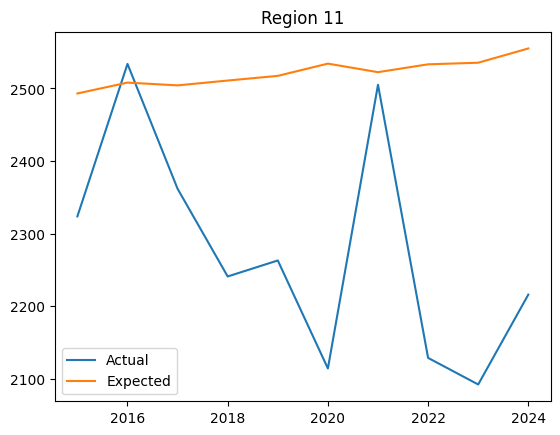

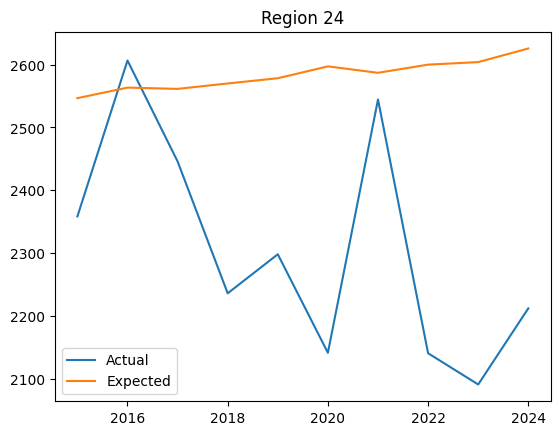

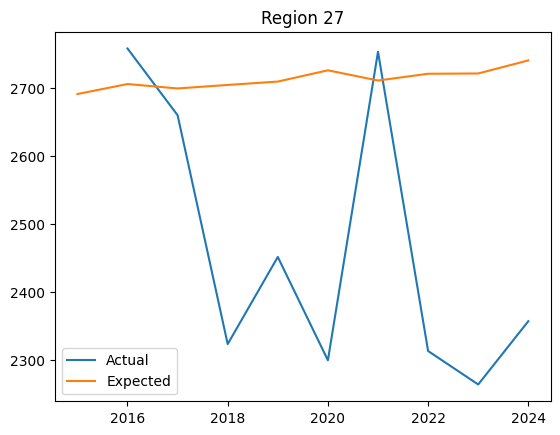

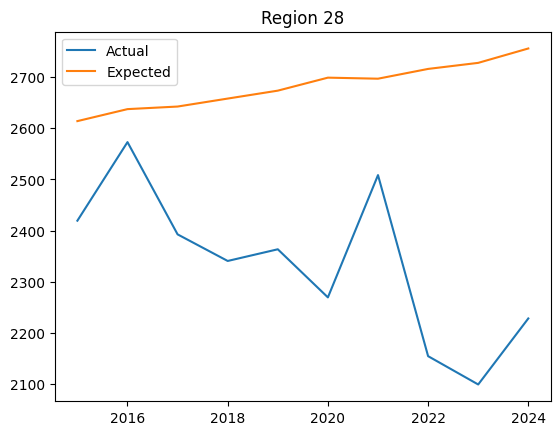

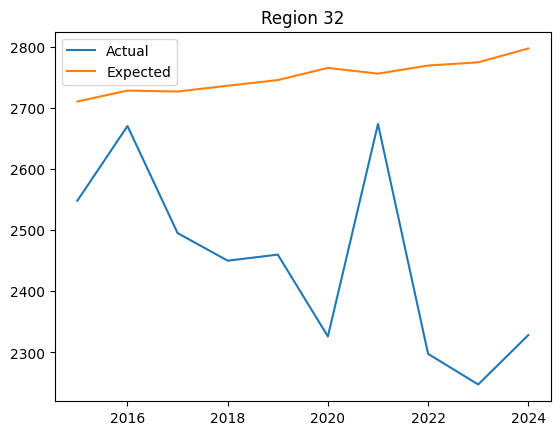

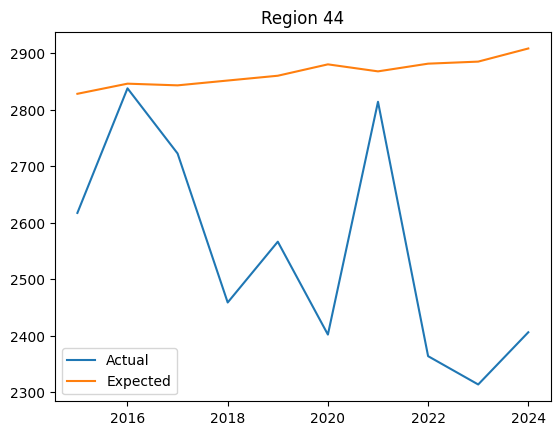

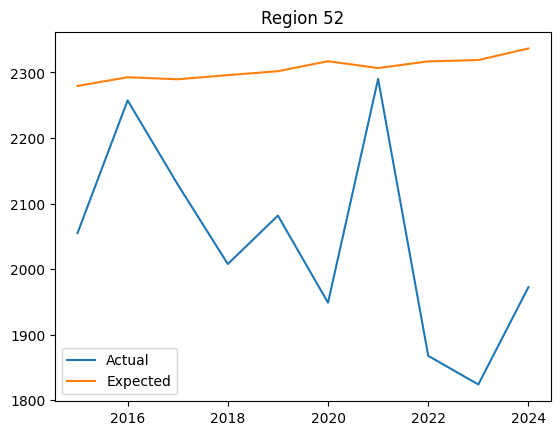

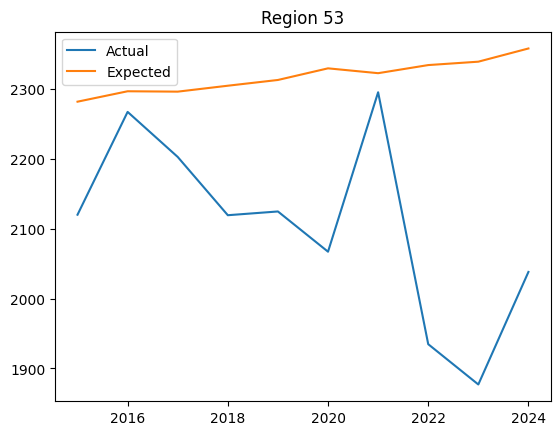

In [161]:
import matplotlib.pyplot as plt

for reg in region_params.keys():
    df_r = df_yearly[df_yearly["region_code"] == reg]

    plt.figure()
    plt.plot(df_r["year"], df_r["actual_hdd"], label="Actual")
    plt.plot(df_r["year"], df_r["expected_hdd"], label="Expected")
    plt.title(f"Region {reg}")
    plt.legend()
    plt.show()